## IMPORT AND SETUP

In [ ]:
!pip install gensim==4.3.2 scipy==1.12.0

In [ ]:
import gensim
print(gensim.__version__)

4.3.2


In [ ]:
import pandas as pd
import numpy as np
import string

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import gensim
import pickle
from scipy.sparse import save_npz, load_npz
from gensim.models.word2vec import Word2Vec

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB

## PREPROCESSING

LOAD DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train-00000-of-00001.parquet to train-00000-of-00001.parquet


In [ ]:
parquet_file_path = 'train-00000-of-00001.parquet'
df = pd.read_parquet(parquet_file_path)
display(df.head())

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [ ]:
# Check class distribution before balancing
print("Before balancing:")
print(df['label'].value_counts())

# Cap each class at 8000 samples
df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 8000), random_state=42)
)

# Shuffle so rows aren't grouped by label
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df['label'].value_counts())

Before balancing:
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

After balancing:
label
4    8000
5    8000
0    8000
2    8000
1    8000
3    8000
Name: count, dtype: int64


/tmp/ipykernel_2064/3279662269.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(


In [ ]:
corpus=df['text'].tolist()
print(f"Corpus loaded: {len(corpus)} documents")
print(f"First document ({len(corpus[0].split())} words):\n{corpus[0][:150]}...")

Corpus loaded: 48000 documents
First document (11 words):
i want to feel suspicious of everyone hehe itll be fun...


TEXT PREPROCESSING

In [ ]:
# convert to lowercase and tokenize
lower_corpus = [i.lower() for i in corpus]
stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'nor', "n't", 'never', 'none'}
stop_words = stop_words - negation_words
words = [word_tokenize(i) for i in lower_corpus]

#remove stopwords and special chars per document then lemmatize
lem = WordNetLemmatizer()
cleaned = []
cleaned_words=[]
for sentence in words:
  cleaned_tokens=[]
  for token in sentence:
        cleaned_token = token.strip(string.punctuation)
        if cleaned_token and cleaned_token not in stop_words and cleaned_token.isalpha():
            lemmatized = lem.lemmatize(cleaned_token)
            cleaned_tokens.append(lemmatized)
  cleaned.append(" ".join(cleaned_tokens))
  cleaned_words.append(cleaned_tokens)

FEATURE EXTRACTION W2V SKIPGRAM

In [ ]:
skipgram = Word2Vec(
    sentences=cleaned_words,
    vector_size=100,
    sg=1,
    window=5,
    epochs=10,
    min_count=10,
    workers=4,
    seed=42
)
skipgram.save("word2vec.model")

print(f"Skip-gram vocab: {len(skipgram.wv)}")
print(f"Successfully saved word2vec model.")

Skip-gram vocab: 3863
Successfully saved word2vec model.


FEATURE EXTRACTION TF-IDF

In [ ]:
tfidf=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    norm='l2')
tfidf_matrix=tfidf.fit_transform((cleaned))

In [ ]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

save_npz('tfidf_vectors.npz', tfidf_matrix)

print(f"Successfully saved vectorizer object in.")
print(f"Successfully saved tfidf matrix.")

Successfully saved vectorizer object in.
Successfully saved tfidf matrix.


# TF-IDF

## LOAD TF-IDF FEATURES

In [ ]:
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

X = load_npz('tfidf_vectors.npz')

print("Vectorizer loaded successfully:", tfidf)
print(f"Features matrix shape: {X.shape}")

# This should print (number_of_rows, 500) because you set max_features=500

Vectorizer loaded successfully: TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)
Features matrix shape: (48000, 5000)


CREATE LABELS MATRIX

In [ ]:
y = df['label']

TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## SVM

Accuracy: 0.9175
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1600
           1       0.93      0.88      0.90      1600
           2       0.91      0.96      0.94      1600
           3       0.94      0.91      0.93      1600
           4       0.90      0.87      0.88      1600
           5       0.89      0.96      0.92      1600

    accuracy                           0.92      9600
   macro avg       0.92      0.92      0.92      9600
weighted avg       0.92      0.92      0.92      9600



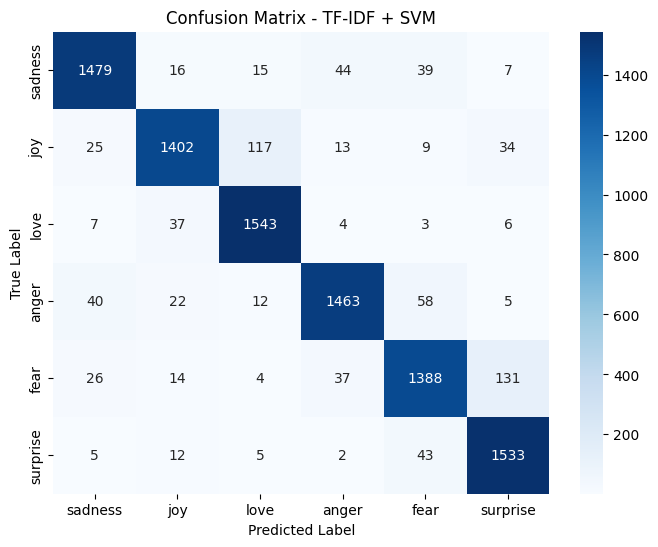

In [ ]:
svm_model = LinearSVC(
    random_state=42, class_weight='balanced'
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - TF-IDF + SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

with open('svm_tfidf_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

##LOGISTIC REGRESSION MODEL

Accuracy: 0.9172916666666666
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1600
           1       0.93      0.88      0.90      1600
           2       0.91      0.96      0.94      1600
           3       0.93      0.92      0.92      1600
           4       0.91      0.86      0.88      1600
           5       0.89      0.97      0.93      1600

    accuracy                           0.92      9600
   macro avg       0.92      0.92      0.92      9600
weighted avg       0.92      0.92      0.92      9600



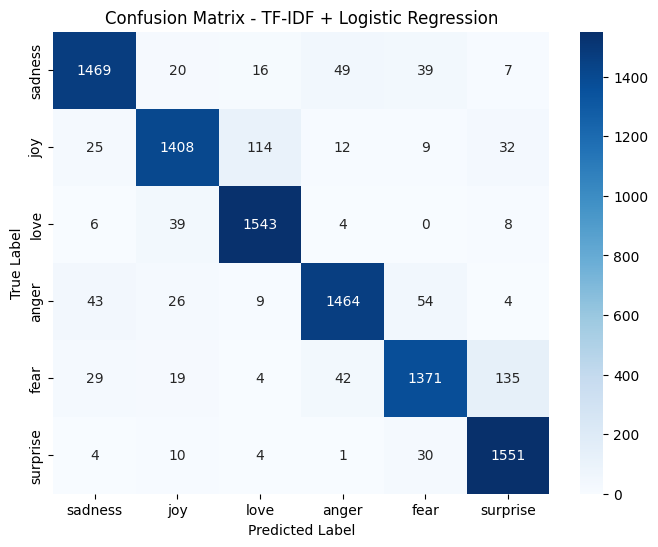

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - TF-IDF + Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

with open('logistic_tfidf_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Word2Vec (SkipGram)

## LOAD Word2Vec MODEL

In [ ]:
w2v_model = Word2Vec.load('word2vec.model')

CONVERT EACH DOC INTO VECTOR

In [ ]:
def document_vector(words):
    valid_words = [w for w in words if w in w2v_model.wv]

    if len(valid_words) == 0:
        return np.zeros(w2v_model.vector_size)

    return np.mean(w2v_model.wv[valid_words], axis=0)

X_w2v = np.array([document_vector(doc) for doc in cleaned_words])

print(X_w2v.shape)

(48000, 100)


CREATE LABELS

In [ ]:
y = df['label']

TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_w2v,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##LOGISTIC REGRESSION MODEL

Accuracy: 0.6461458333333333
              precision    recall  f1-score   support

           0       0.56      0.55      0.55      1600
           1       0.61      0.64      0.63      1600
           2       0.71      0.74      0.73      1600
           3       0.64      0.60      0.62      1600
           4       0.62      0.61      0.61      1600
           5       0.74      0.74      0.74      1600

    accuracy                           0.65      9600
   macro avg       0.65      0.65      0.65      9600
weighted avg       0.65      0.65      0.65      9600



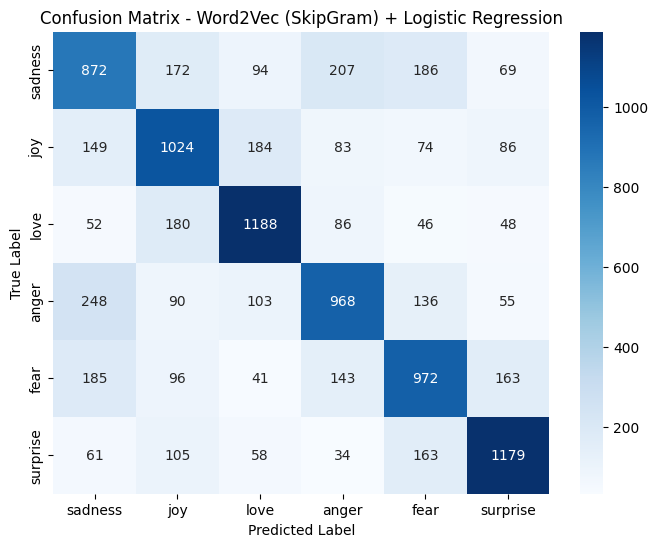

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - Word2Vec (SkipGram) + Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

with open('w2v_logistic_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

##SVM MODEL

Accuracy: 0.646875
              precision    recall  f1-score   support

           0       0.57      0.50      0.53      1600
           1       0.62      0.64      0.63      1600
           2       0.69      0.76      0.72      1600
           3       0.64      0.61      0.62      1600
           4       0.63      0.61      0.62      1600
           5       0.72      0.76      0.74      1600

    accuracy                           0.65      9600
   macro avg       0.64      0.65      0.64      9600
weighted avg       0.64      0.65      0.64      9600



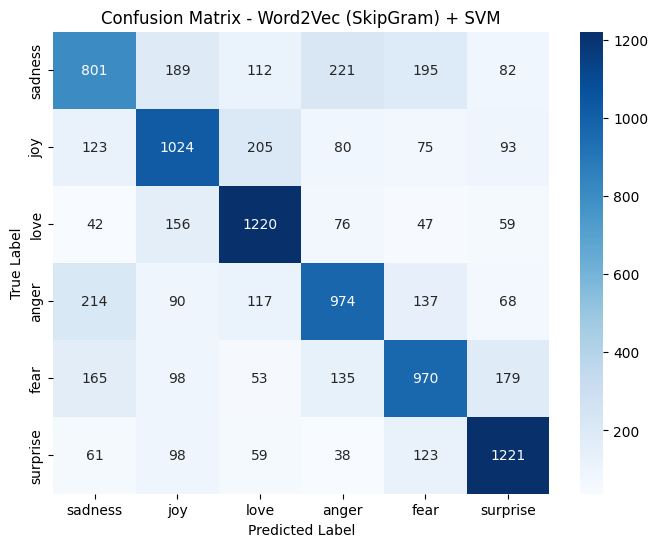

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - Word2Vec (SkipGram) + SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

with open('w2v_svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)